In [2]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    roc_curve,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

import tensorflow as tf

2026-02-21 18:21:43.710742: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-02-21 18:21:43.711005: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-02-21 18:21:43.743404: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-02-21 18:21:44.556524: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation or

In [3]:

def build_model(input_dim: int) -> tf.keras.Model:
    # 3 warstwy: Dense -> Dense -> Output
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(input_dim,)),
        tf.keras.layers.Dense(64, activation="relu"),
        tf.keras.layers.Dense(32, activation="relu"),
        tf.keras.layers.Dense(1, activation="sigmoid"),
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss="binary_crossentropy",
        metrics=[
            tf.keras.metrics.BinaryAccuracy(name="accuracy"),
            tf.keras.metrics.AUC(name="auc")
        ],
    )
    return model

In [6]:

def main():
    # Reproducibility (w granicach rozsądku na CPU)
    np.random.seed(42)
    tf.random.set_seed(42)

    # 1) Dane
    data = load_breast_cancer()
    X = data.data.astype(np.float32)
    y = data.target.astype(np.int32)  # 0/1

    # 2) Split: train/val/test
    X_train, X_temp, y_train, y_temp = train_test_split(
        X, y, test_size=0.30, random_state=42, stratify=y
    )
    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
    )

    # 3) Standaryzacja (fit tylko na train!)
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train).astype(np.float32)
    X_val = scaler.transform(X_val).astype(np.float32)
    X_test = scaler.transform(X_test).astype(np.float32)

    # 4) Model
    model = build_model(input_dim=X_train.shape[1])
    model.summary()

    # 5) Trening
    callbacks = [
        tf.keras.callbacks.EarlyStopping(
            monitor="val_auc",
            mode="max",
            patience=10,
            restore_best_weights=True
        )
    ]

    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=100,
        batch_size=32,
        callbacks=callbacks,
        verbose=1
    )

    # 6) Ewaluacja na teście (Keras)
    test_loss, test_acc, test_auc = model.evaluate(X_test, y_test, verbose=0)
    print("\n=== Keras evaluate (TEST) ===")
    print(f"loss: {test_loss:.4f}")
    print(f"accuracy: {test_acc:.4f}")
    print(f"auc: {test_auc:.4f}")

    # 7) Predykcje + metryki sklearn
    y_proba = model.predict(X_test, verbose=0).ravel()          # prawdopodobieństwa klasy 1
    y_pred = (y_proba >= 0.5).astype(np.int32)                 # predykcja 0/1 przy progu 0.5

    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)
    print("\n=== Sklearn scoring (TEST) ===")
    print(f"accuracy_score: {acc:.4f}")
    print(f"roc_auc_score: {auc:.4f}")

    print("\n=== Classification report (TEST) ===")
    print(classification_report(y_test, y_pred, target_names=data.target_names))

    # 8) Macierz pomyłek
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=data.target_names)
    disp.plot(values_format="d")
    plt.title("Confusion Matrix (TEST)")
    plt.tight_layout()
    plt.show()

    # 9) ROC curve
    fpr, tpr, thresholds = roc_curve(y_test, y_proba)
    plt.figure()
    plt.plot(fpr, tpr, label=f"ROC (AUC={auc:.3f})")
    plt.plot([0, 1], [0, 1], linestyle="--", label="Random")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve (TEST)")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # 10) Wizualizacja uczenia: loss i auc
    hist = history.history
    epochs = range(1, len(hist["loss"]) + 1)

    plt.figure()
    plt.plot(epochs, hist["loss"], label="train_loss")
    plt.plot(epochs, hist["val_loss"], label="val_loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training Curve: Loss")
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure()
    plt.plot(epochs, hist["auc"], label="train_auc")
    plt.plot(epochs, hist["val_auc"], label="val_auc")
    plt.xlabel("Epoch")
    plt.ylabel("AUC")
    plt.title("Training Curve: AUC")
    plt.legend()
    plt.tight_layout()
    plt.show()

2026-02-21 18:22:49.731792: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,097 (16.00 KB)

 Trainable params: 4,097 (16.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.7864 - auc: 0.9433 - loss: 0.4619 - val_accuracy: 0.9529 - val_auc: 0.9873 - val_loss: 0.3449
Epoch 2/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9397 - auc: 0.9815 - loss: 0.2717 - val_accuracy: 0.9647 - val_auc: 0.9894 - val_loss: 0.2166
Epoch 3/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9523 - auc: 0.9866 - loss: 0.1872 - val_accuracy: 0.9647 - val_auc: 0.9959 - val_loss: 0.1499
Epoch 4/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9598 - auc: 0.9909 - loss: 0.1410 - val_accuracy: 0.9647 - val_auc: 0.9988 - val_loss: 0.1117
Epoch 5/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9749 - auc: 0.9931 - loss: 0.1132 - val_accuracy: 0.9765 - val_auc: 0.9988 - val_loss: 0.0892
Epoch 6/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9799 - auc: 0.9944 - loss: 0.0959 - val_accuracy: 0.9765 - val_auc: 0.9994 - val_loss: 0.0753
Epoch 7/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms

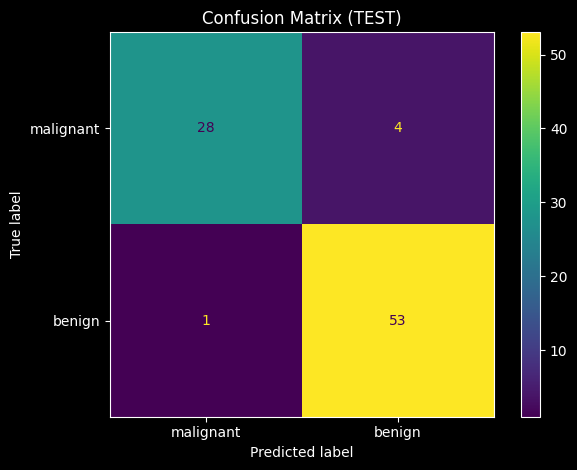

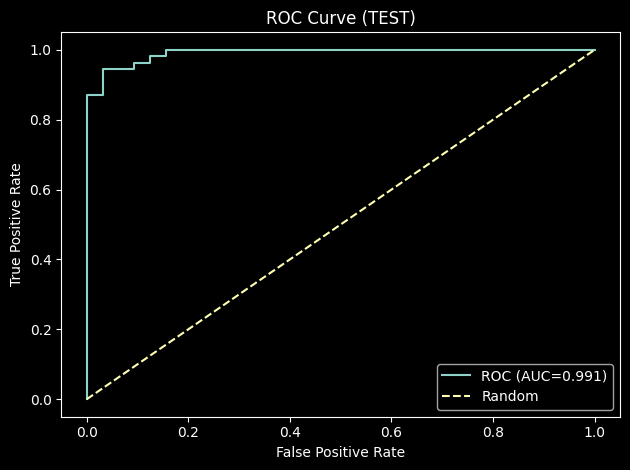

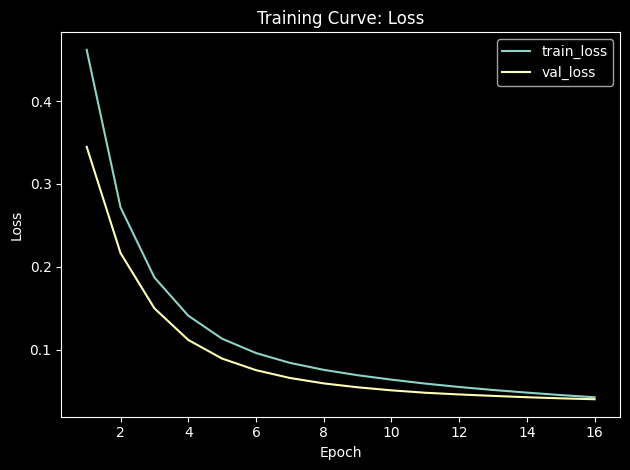

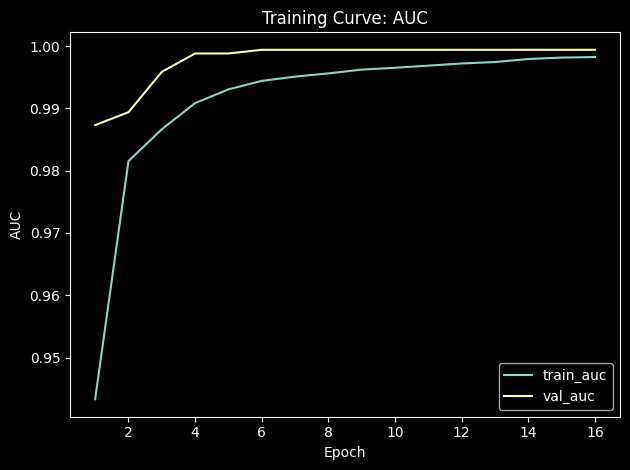

In [7]:
main()